## TD:

- Other models
- Hyperparameter tuning

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import roc_curve, roc_auc_score

df = pd.read_csv(r"C:\Users\lexgu\Downloads\UR3 CobotOps Data - Sheet1.csv")
columns_to_drop = ['Timestamp']
df = df.drop(columns = columns_to_drop, axis=1)
df


,Num,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,...,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,False,False
1,2,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,...,-7.390000e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,False,False
2,3,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,...,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,False,False
3,4,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,...,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,False,False
4,5,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,...,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,7405,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,264,False,False
7405,7406,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,264,False,False
7406,7407,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,264,False,False
7407,7408,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,264,False,False


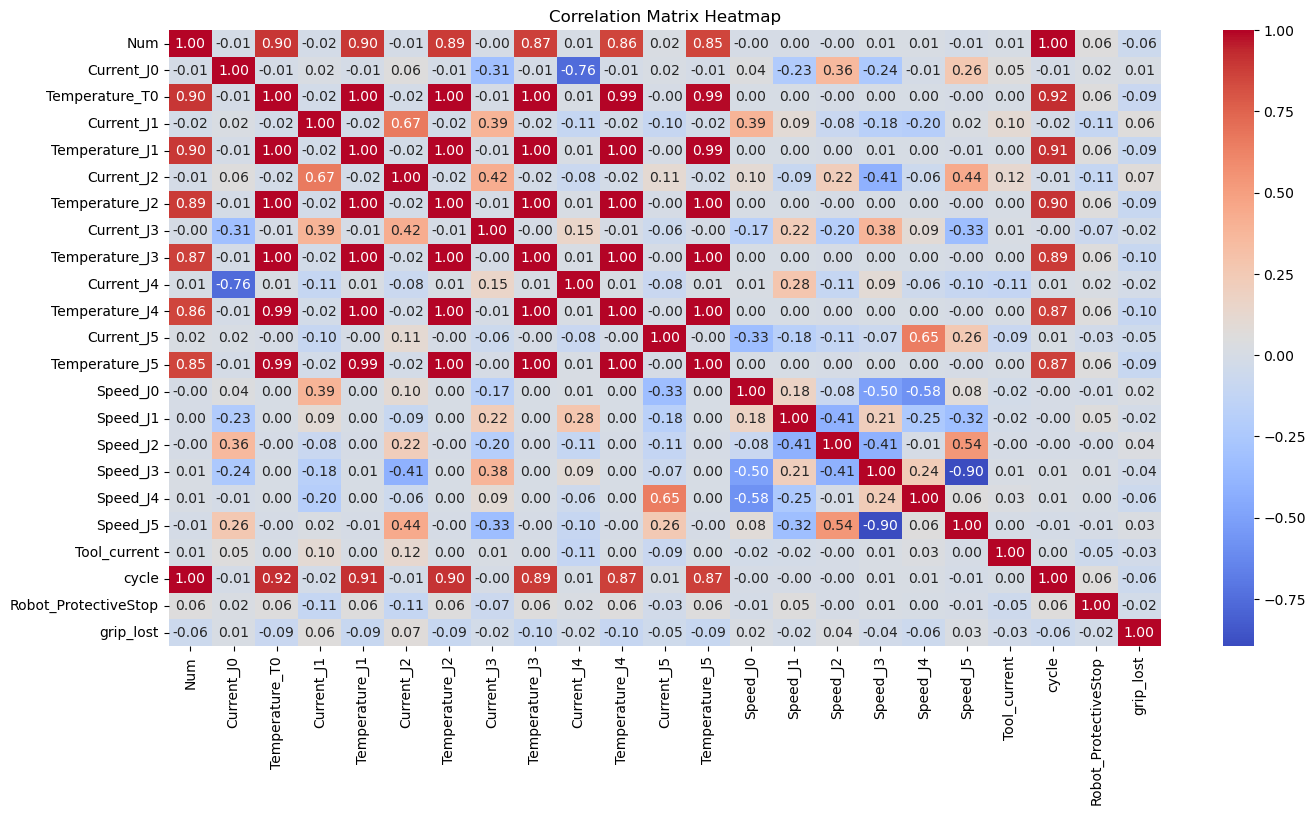

In [3]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [4]:
#dataframe with only speed + grip_lost

columns_to_drop = ['Num', 'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Temperature_T0', 'Temperature_J1', 'Temperature_J2', 'Temperature_J3', 'Temperature_J4', 'Temperature_J5', 'cycle', 'Tool_current', 'Robot_ProtectiveStop']
df_1 = df.drop(columns = columns_to_drop, axis=1)
#clean data
df_cleaned = df_1.dropna()

#make speed values only positive
columns_to_modify = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']

for column in columns_to_modify:
    df_cleaned[column] = df_cleaned[column].abs()

df_cleaned

C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\222248936.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[column] = df_cleaned[column].abs()


,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,grip_lost
0,2.955651e-01,0.000490,0.001310,0.132836,0.007479,0.152962,False
1,7.390000e-30,0.000304,0.002185,0.001668,0.000767,0.000417,False
2,1.369386e-01,0.007795,2.535874,0.379867,0.000455,0.496856,False
3,9.030032e-02,0.004911,0.009096,0.384196,0.018411,0.425559,False
4,1.268088e-01,0.005567,0.001138,0.353284,0.014994,0.180989,False
...,...,...,...,...,...,...,...
7404,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,False
7405,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,False
7406,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,False
7407,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,False


In [5]:
#remove rows where all features = 0

df_cleaned = df_cleaned.loc[~(df_cleaned == 0).all(axis=1)]
df_cleaned

,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,grip_lost
0,2.955651e-01,0.000490,1.310194e-03,1.328356e-01,0.007479,0.152962,False
1,7.390000e-30,0.000304,2.185137e-03,1.668227e-03,0.000767,0.000417,False
2,1.369386e-01,0.007795,2.535874e+00,3.798670e-01,0.000455,0.496856,False
3,9.030032e-02,0.004911,9.096014e-03,3.841961e-01,0.018411,0.425559,False
4,1.268088e-01,0.005567,1.138345e-03,3.532840e-01,0.014994,0.180989,False
...,...,...,...,...,...,...,...
7398,7.402850e-03,0.183715,3.703889e-01,9.463752e-03,0.000351,0.135950,False
7399,1.288373e-01,0.017049,9.448170e-03,1.612025e-01,0.047146,0.055798,False
7400,5.060138e-02,0.000000,2.200000e-16,1.376524e-02,0.001019,0.024078,False
7401,1.398979e-01,0.000353,3.307879e-03,1.283190e-01,0.005365,0.006288,False


In [6]:
true_count = df_cleaned['grip_lost'].sum()

print("Number of True values in 'grip_lost' column:", true_count)



Number of True values in 'grip_lost' column: 243


<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\1414472545.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\classimbalance\pichar_fvst.png')


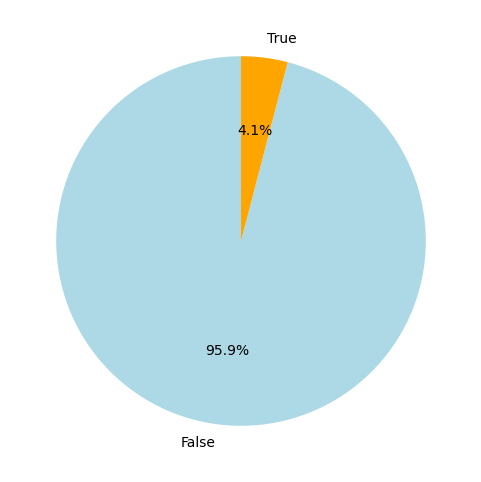

In [7]:
# Manually entered categories and percentages
categories = ['False', 'True']
percentages = [95.930329928, 4.069670072]  # For example, 70% False and 30% True

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(percentages, labels=categories, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
#plt.title('Percentage of False vs True in grip_lost Column')
plt.savefig('C:\plots\classimbalance\pichar_fvst.png')
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\2285700337.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\classimbalance\countplot_fvst.png')


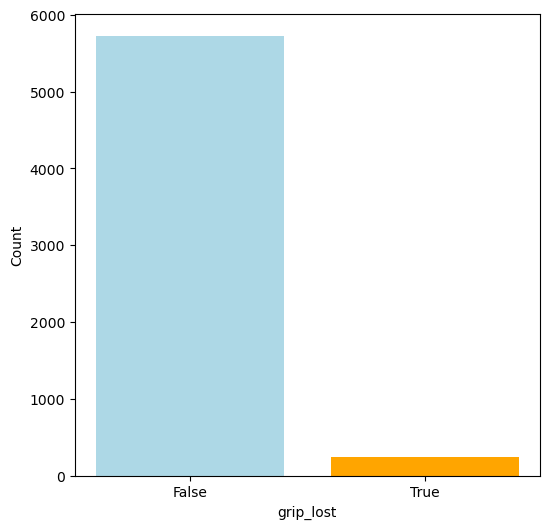

In [8]:
categories = ['False', 'True']
counts = [5728, 243]  # For example, 4200 False and 1771 True

# Plot bar chart
plt.figure(figsize=(6, 6))
plt.bar(categories, counts, color=['lightblue', 'orange'])
plt.xlabel('grip_lost')
plt.ylabel('Count')
#plt.title('Count of False vs True in grip_lost Column')
plt.xticks(rotation=0)
plt.savefig('C:\plots\classimbalance\countplot_fvst.png')
plt.show()

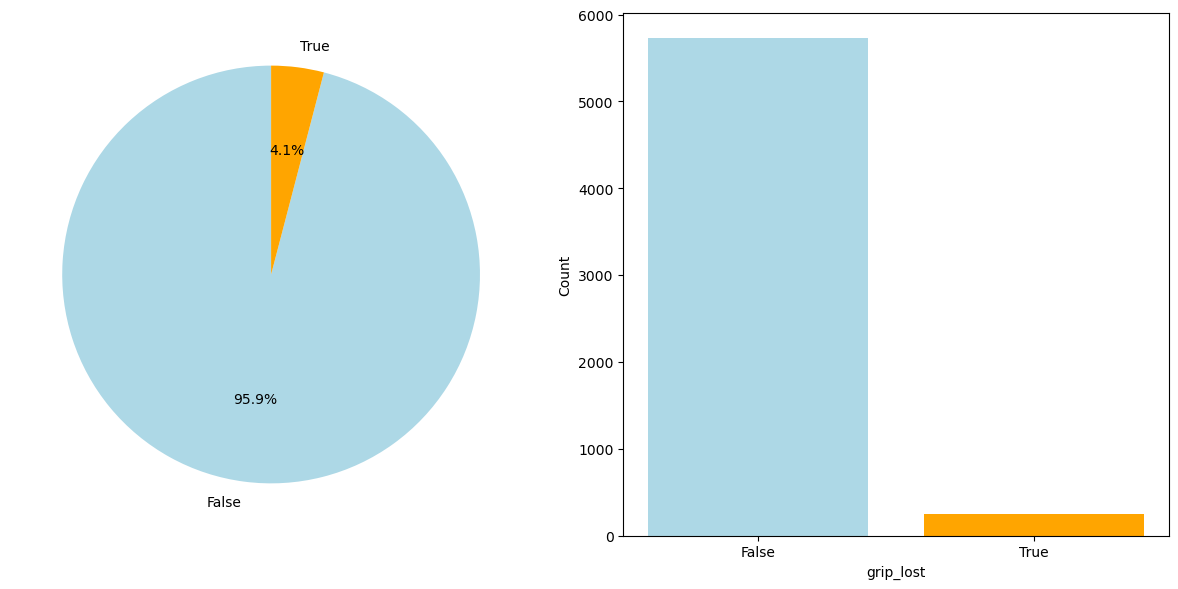

In [9]:
categories = ['False', 'True']
percentages = [95.93, 4.07]  # Rounded to 2 decimal places for clarity

# Manually entered counts for the bar chart
counts = [5728, 243]

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot pie chart on the first subplot
axs[0].pie(percentages, labels=categories, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
#axs[0].set_title('Percentage of False vs True in grip_lost Column')

# Plot bar chart on the second subplot
axs[1].bar(categories, counts, color=['lightblue', 'orange'])
axs[1].set_xlabel('grip_lost')
axs[1].set_ylabel('Count')
#axs[1].set_title('Count of False vs True in grip_lost Column')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(categories)

# Adjust layout
plt.tight_layout()

# Save the combined plot
plt.savefig('C:\\plots\\classimbalance\\combined_plot.png')

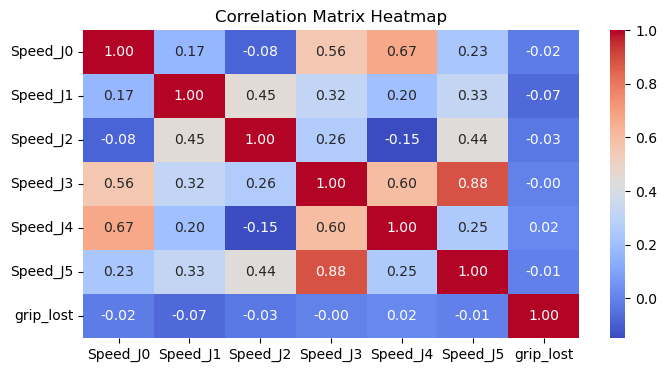

In [10]:
plt.figure(figsize=(8, 4))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [40]:
#Split dataset into training and testing sets

X = df_cleaned.drop('grip_lost', axis = 1)

y = df_cleaned['grip_lost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)


In [12]:
#generatic synthetic samples for minority class using SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train

,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5
0,0.000000,1.540000e-43,0.000000e+00,0.000029,0.000000e+00,0.000038
1,0.000000,1.566940e-04,4.560000e-25,0.001051,0.000000e+00,0.000073
2,0.532631,2.321450e-04,1.810300e-02,0.287956,1.708725e-02,0.274231
3,0.282825,6.349570e-04,6.187117e-03,0.231651,9.736068e-03,0.050953
4,0.000066,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000062
...,...,...,...,...,...,...
8025,0.171319,5.751485e-03,4.384939e-03,0.447861,8.737541e-02,0.223122
8026,0.080691,3.702140e-03,2.637694e-04,0.111491,2.850819e-02,0.022453
8027,0.019754,1.136088e-03,3.158770e-05,0.039283,7.528083e-03,0.010881
8028,0.000540,2.643362e-03,2.603127e+00,0.586411,2.378737e-15,0.643392


In [13]:
#class weighting

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f'Class weights: {class_weights_dict}')

Class weights: {0: 1.0, 1: 1.0}


In [14]:
#Initialize and train the models
#Logisitc Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_test)

In [15]:
dec_tree = DecisionTreeClassifier() #creating the model
dec_tree.fit(X_train, y_train) #training the model
dec_tree_pred = dec_tree.predict(X_test) #using the model for predictions (with X_test)

In [16]:
#Random Forest
rand_forest = RandomForestClassifier()
rand_forest.fit(X_train, y_train)
rand_forest_pred = rand_forest.predict(X_test)

In [17]:
#Support Vector Machine
svc = SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

In [18]:
#XGBoost
xgboost = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgboost.fit(X_train, y_train)
xgboost_pred = xgboost.predict(X_test)

C:\Users\lexgu\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:53:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [19]:
#Tuned XGBoost

bestParams = {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
xgboost_tuned = xgb.XGBClassifier(**bestParams)
xgboost_tuned.fit(X_train, y_train)
xgboost_tuned_pred = xgboost_tuned.predict(X_test)

In [20]:
#Tuned XGB 2
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(xgboost, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
xgboost_tuned2_pred = best_model.predict(X_test)

xgboost_tuned_results = {
    'Accuracy': accuracy_score(y_test, xgboost_tuned2_pred),
    'Precision': precision_score(y_test, xgboost_tuned2_pred, zero_division=1),
    'Recall': recall_score(y_test, xgboost_tuned2_pred, zero_division=1),
    'F1 Score': f1_score(y_test, xgboost_tuned2_pred, zero_division=1)
}
print(xgboost_tuned_results)




{'Accuracy': 0.9263392857142857, 'Precision': 0.2809917355371901, 'Recall': 0.43037974683544306, 'F1 Score': 0.34}


In [21]:
#KNN

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [22]:
#Evaluate models

log_reg_results = {
    'Accuracy': accuracy_score(y_test, log_reg_pred),
    'Precision': precision_score(y_test, log_reg_pred, zero_division=1),
    'Recall': recall_score(y_test, log_reg_pred, zero_division=1),
    'F1 Score': f1_score(y_test, log_reg_pred, zero_division=1)
}

dec_tree_results = {
    'Accuracy': accuracy_score(y_test, dec_tree_pred),
    'Precision': precision_score(y_test, dec_tree_pred, zero_division=1),
    'Recall': recall_score(y_test, dec_tree_pred, zero_division=1),
    'F1 Score': f1_score(y_test, dec_tree_pred, zero_division=1)
}

rand_forest_results = {
    'Accuracy': accuracy_score(y_test, rand_forest_pred),
    'Precision': precision_score(y_test, rand_forest_pred, zero_division=1),
    'Recall': recall_score(y_test, rand_forest_pred, zero_division=1),
    'F1 Score': f1_score(y_test, rand_forest_pred, zero_division=1)
}

svc_results = {
    'Accuracy': accuracy_score(y_test, svc_pred),
    'Precision': precision_score(y_test, svc_pred, zero_division=1),
    'Recall': recall_score(y_test, svc_pred, zero_division=1),
    'F1 Score': f1_score(y_test, svc_pred, zero_division=1)
}

xgboost_results = {
    'Accuracy': accuracy_score(y_test, xgboost_pred),
    'Precision': precision_score(y_test, xgboost_pred, zero_division=1),
    'Recall': recall_score(y_test, xgboost_pred, zero_division=1),
    'F1 Score': f1_score(y_test, xgboost_pred, zero_division=1)
}

knn_results = {
    'Accuracy': accuracy_score(y_test, knn_pred),
    'Precision': precision_score(y_test, knn_pred, zero_division=1),
    'Recall': recall_score(y_test, knn_pred, zero_division=1),
    'F1 Score': f1_score(y_test, knn_pred, zero_division=1)
}


print(log_reg_results)
print(dec_tree_results)
print(rand_forest_results)
print(svc_results)
print(xgboost_results)
print(knn_results)

{'Accuracy': 0.4017857142857143, 'Precision': 0.04986400725294651, 'Recall': 0.6962025316455697, 'F1 Score': 0.09306260575296109}
{'Accuracy': 0.8498883928571429, 'Precision': 0.14285714285714285, 'Recall': 0.4810126582278481, 'F1 Score': 0.22028985507246376}
{'Accuracy': 0.8660714285714286, 'Precision': 0.16317991631799164, 'Recall': 0.4936708860759494, 'F1 Score': 0.24528301886792453}
{'Accuracy': 0.7622767857142857, 'Precision': 0.06733167082294264, 'Recall': 0.34177215189873417, 'F1 Score': 0.1125}
{'Accuracy': 0.9202008928571429, 'Precision': 0.25757575757575757, 'Recall': 0.43037974683544306, 'F1 Score': 0.3222748815165877}
{'Accuracy': 0.8443080357142857, 'Precision': 0.14788732394366197, 'Recall': 0.5316455696202531, 'F1 Score': 0.23140495867768596}


In [23]:
#Combine results into a DataFrame
results_df = pd.DataFrame({
    'Logistic Regression': log_reg_results,
    'Decision Tree': dec_tree_results,
    'Random Forest': rand_forest_results,
    'Support Vector Machines': svc_results,
    'XGBoost' : xgboost_results,
    'K-Nearest Neighbors' : knn_results
}).T #transpose, columns turn into rows

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.401786,0.049864,0.696203,0.093063
Decision Tree,0.849888,0.142857,0.481013,0.220290
Random Forest,0.866071,0.163180,0.493671,0.245283
Support Vector Machines,0.762277,0.067332,0.341772,0.112500
XGBoost,0.920201,0.257576,0.430380,0.322275
K-Nearest Neighbors,0.844308,0.147887,0.531646,0.231405


In [24]:
#Evaluate tuned models

xgboost_tuned_results = {
    'Accuracy': accuracy_score(y_test, xgboost_tuned_pred),
    'Precision': precision_score(y_test, xgboost_tuned_pred, zero_division=1),
    'Recall': recall_score(y_test, xgboost_tuned_pred, zero_division=1),
    'F1 Score': f1_score(y_test, xgboost_tuned_pred, zero_division=1)
}

In [25]:
print(xgboost_tuned_results)

{'Accuracy': 0.9207589285714286, 'Precision': 0.26666666666666666, 'Recall': 0.45569620253164556, 'F1 Score': 0.3364485981308411}


In [26]:
rand_forest_tuned_results = {'Accuracy': 0.9587053571428571, 'Precision': 0.5609756097560976, 'Recall': 0.2911392405063291, 'F1 Score': 0.38333333333333336}

In [27]:
results_df = pd.DataFrame({
    'Logistic Regression': log_reg_results,
    'Decision Tree': dec_tree_results,
    'Random Forest': rand_forest_results,
    'Random Forest Tuned' : rand_forest_tuned_results,
    'Support Vector Machines': svc_results,
    'XGBoost' : xgboost_results,
    'XGBoost Tuned' : xgboost_tuned_results,
    'K-Nearest Neighbors' : knn_results
}).T #transpose, columns turn into rows

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.401786,0.049864,0.696203,0.093063
Decision Tree,0.849888,0.142857,0.481013,0.220290
Random Forest,0.866071,0.163180,0.493671,0.245283
Random Forest Tuned,0.958705,0.560976,0.291139,0.383333
Support Vector Machines,0.762277,0.067332,0.341772,0.112500
XGBoost,0.920201,0.257576,0.430380,0.322275
XGBoost Tuned,0.920759,0.266667,0.455696,0.336449
K-Nearest Neighbors,0.844308,0.147887,0.531646,0.231405


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\3133161678.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\confusion_matrices\confusion_matrix.png')


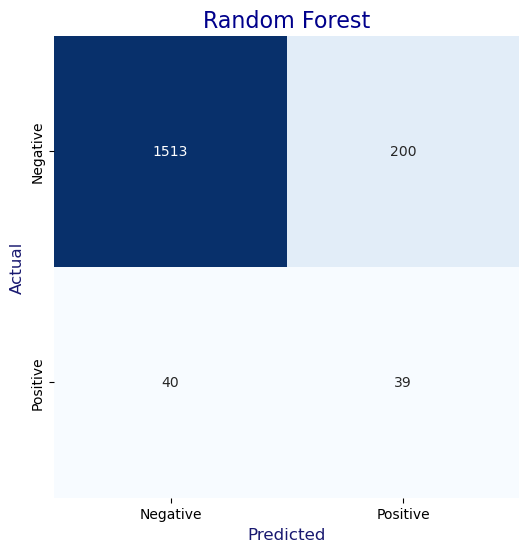

In [28]:
# Compute confusion matrix
cm = confusion_matrix(y_test, rand_forest_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Random Forest', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:\plots\confusion_matrices\confusion_matrix.png')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\3133161678.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\confusion_matrices\confusion_matrix.png')


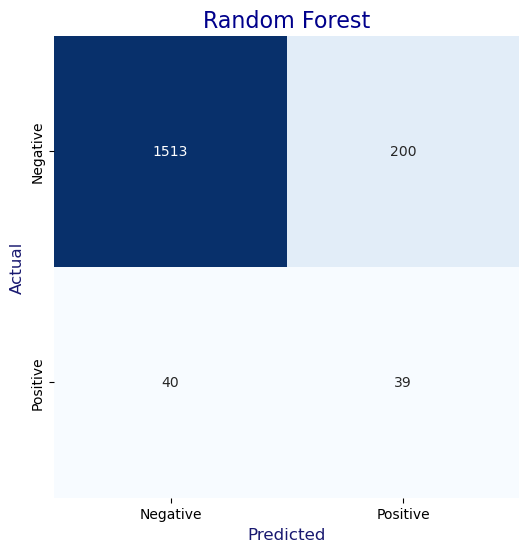

In [29]:
# Compute confusion matrix
cm = confusion_matrix(y_test, rand_forest_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Random Forest', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:\plots\confusion_matrices\confusion_matrix.png')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\1078490864.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\confusion_matrices\logreg.png')


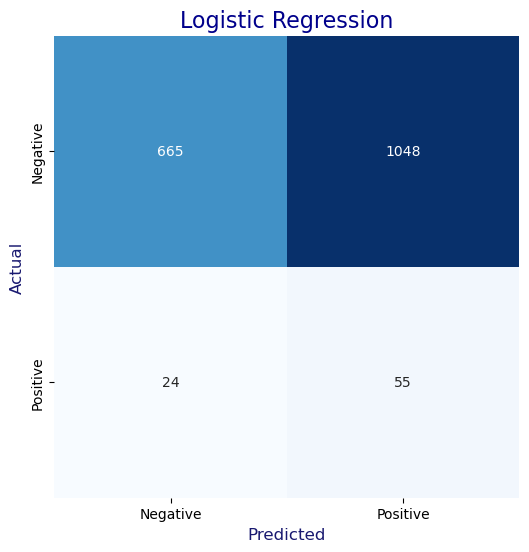

In [30]:
# Compute confusion matrix
cm = confusion_matrix(y_test, log_reg_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Logistic Regression', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:\plots\confusion_matrices\logreg.png')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\1612017661.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\confusion_matrices\svc.png')


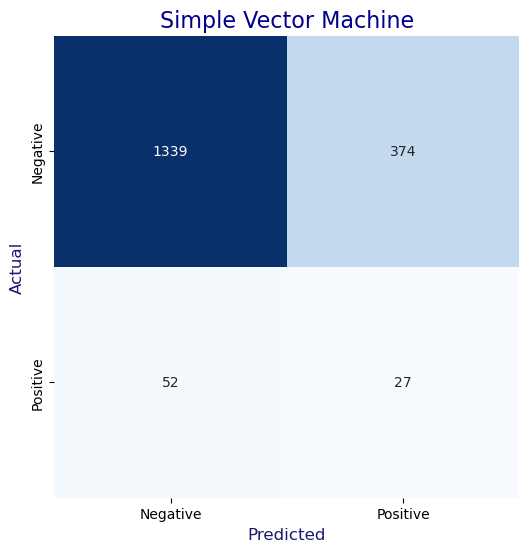

In [31]:
# Compute confusion matrix
cm = confusion_matrix(y_test, svc_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Simple Vector Machine', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:\plots\confusion_matrices\svc.png')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lexgu\AppData\Local\Temp\ipykernel_23996\2686166445.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig('C:\plots\confusion_matrices\dectree.png')


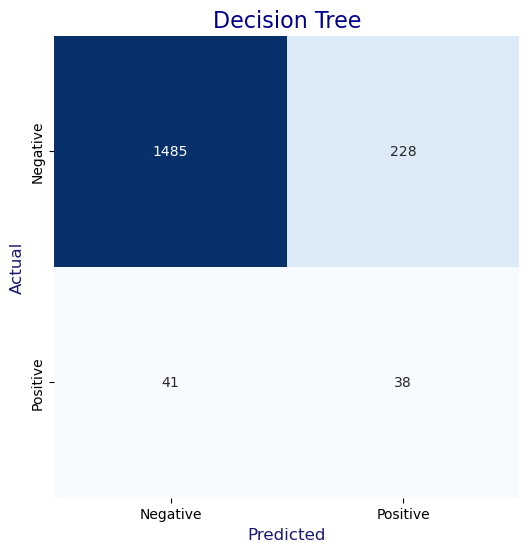

In [32]:
# Compute confusion matrix
cm = confusion_matrix(y_test, dec_tree_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Decision Tree', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:\plots\confusion_matrices\dectree.png')

plt.show()

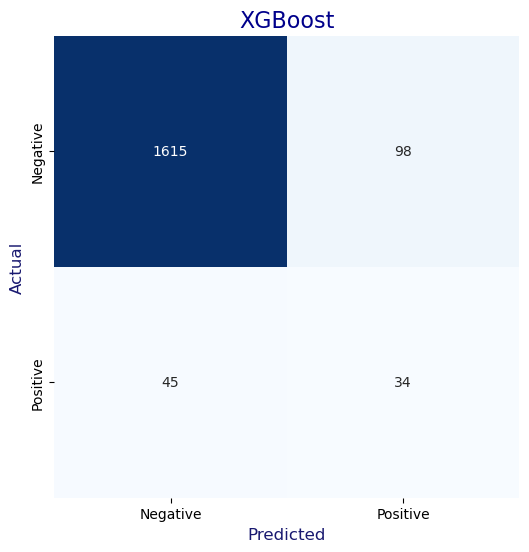

In [33]:
# Compute confusion matrix
cm = confusion_matrix(y_test, xgboost_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('XGBoost', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:/plots/confusion_matrices/xgb.png')

plt.show()

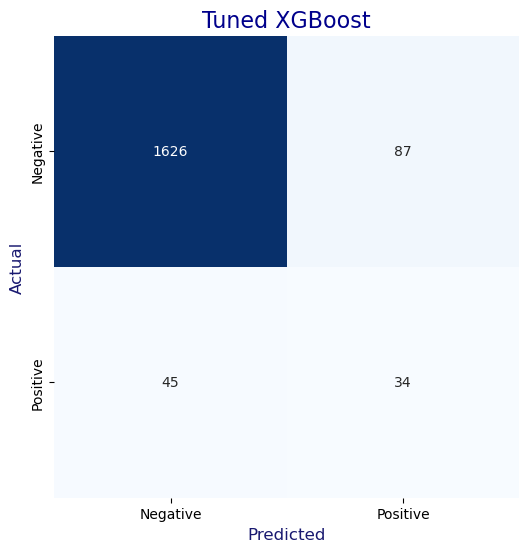

In [34]:
# Compute confusion matrix
cm = confusion_matrix(y_test, xgboost_tuned2_pred )

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Tuned XGBoost', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:/plots/confusion_matrices/tunedxgb.png')

plt.show()

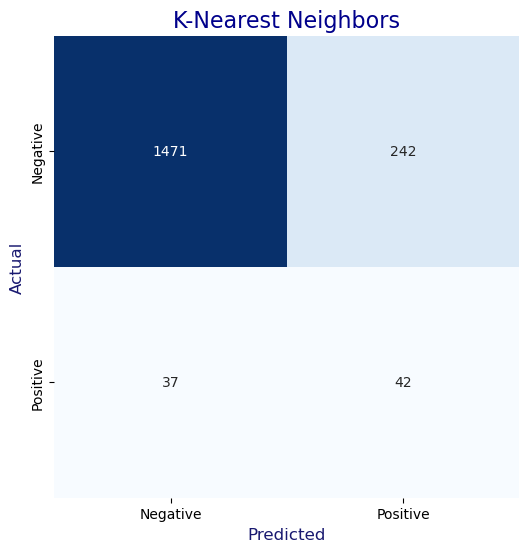

In [35]:
# Compute confusion matrix
cm = confusion_matrix(y_test, knn_pred )

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('K-Nearest Neighbors', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')
plt.savefig('C:/plots/confusion_matrices/knn.png')

plt.show()

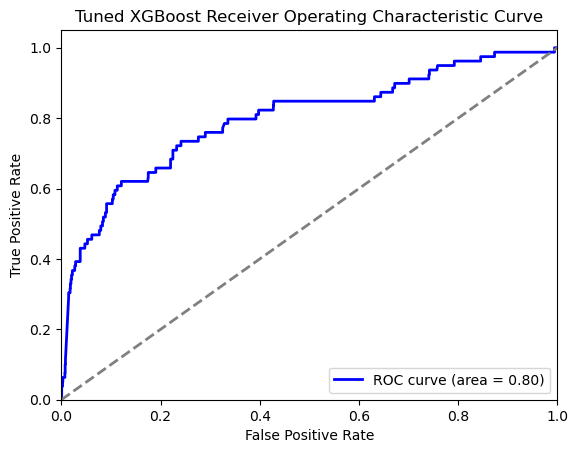

In [36]:
#tuned xgboost ROC curve
xgb_tuned_prob = xgboost_tuned.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, xgb_tuned_prob)
roc_auc = roc_auc_score(y_test, xgb_tuned_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned XGBoost Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.savefig('C:/plots/ROC_curves/xgboostROC.png')
plt.show()

In [37]:
importances = xgboost_tuned.feature_importances_
feature_names = X_train.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances

,Feature,Importance
0,Speed_J0,0.162721
1,Speed_J1,0.221593
2,Speed_J2,0.137619
3,Speed_J3,0.168887
4,Speed_J4,0.190023
5,Speed_J5,0.119155


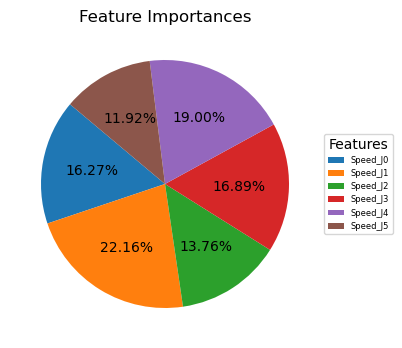

In [38]:
plt.figure(figsize=(4,4))
plt.title('Feature Importances')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
wedges, texts, autotexts = plt.pie(feature_importances['Importance'], autopct='%1.2f%%', startangle=140)
plt.legend(wedges, feature_importances['Feature'], title="Features", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), prop={'size': 6})
plt.show()